## Importing Libraries & Loading the Simulated Dataset

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('smart_meter_simulated.csv', parse_dates=['Timestamp'])
df['Anomaly_Type'] = df['Anomaly_Type'].fillna('None')  # CSV quirk: "None" string reads as NaN

print(df.shape)
df.head()

(104832, 10)


,Meter_ID,Segment,Timestamp,Electricity_Consumed_kWh,Temperature_C,Humidity_pct,Wind_Speed_kmh,Is_Load_Shedding,Anomaly_Type,Anomaly_Label
0,RH01,residential_high,2024-01-01 00:00:00,0.189380,20.303021,56.505605,1.897249,False,None,Normal
1,RH01,residential_high,2024-01-01 00:30:00,0.191745,18.833074,53.669278,4.403007,False,None,Normal
2,RH01,residential_high,2024-01-01 01:00:00,0.191663,19.575971,67.036984,0.978868,False,None,Normal
3,RH01,residential_high,2024-01-01 01:30:00,0.180723,20.541858,42.869897,7.101429,False,None,Normal
4,RH01,residential_high,2024-01-01 02:00:00,0.205485,17.653805,50.162334,15.107731,False,None,Normal


## Basic Exploratory Data Analysis

In [0]:
print(df.columns)

Index(['Meter_ID', 'Segment', 'Timestamp', 'Electricity_Consumed_kWh',
       'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Is_Load_Shedding',
       'Anomaly_Type', 'Anomaly_Label'],
      dtype='object')


In [0]:
df['Meter_ID'].nunique()

12

We have a total of 12 unique meter IDs

In [0]:
# Checking for missing values
print("Missing values:\n", df.isnull().sum())


Missing values:
 Meter_ID                    0
Segment                     0
Timestamp                   0
Electricity_Consumed_kWh    0
Temperature_C               0
Humidity_pct                0
Wind_Speed_kmh              0
Is_Load_Shedding            0
Anomaly_Type                0
Anomaly_Label               0
dtype: int64


There are no missing values in the dataset

In [0]:
# Counting different anomaly labels
df['Anomaly_Label'].value_counts()

Anomaly_Label
Normal      86660
Abnormal    18172
Name: count, dtype: int64

In [0]:
# Counting anomaly type values
df['Anomaly_Type'].value_counts()

Anomaly_Type
None                  86660
Calibration_Drift     11368
Meter_Tampering        3648
Illegal_Connection     1852
Stuck_Meter            1304
Name: count, dtype: int64

In [0]:
# Calculating number of unique meter IDs per segment
df.groupby("Segment")["Meter_ID"].nunique()

Segment
residential_high    5
residential_low     5
small_business      2
Name: Meter_ID, dtype: int64

In [0]:
df['Is_Load_Shedding'].value_counts()

Is_Load_Shedding
False    102864
True       1968
Name: count, dtype: int64

## Feature Enginnering (Time Columns)

In [0]:
# Creating new columns for the time
df['hour'] = df['Timestamp'].dt.hour + df['Timestamp'].dt.minute/60
df['dow'] = df['Timestamp'].dt.dayofweek
df['is_weekend'] = (df['dow'] >= 5).astype(int)
df['month'] = df['Timestamp'].dt.month

## EDA Visuals: daily curve, seasonality, weather, anomaly types

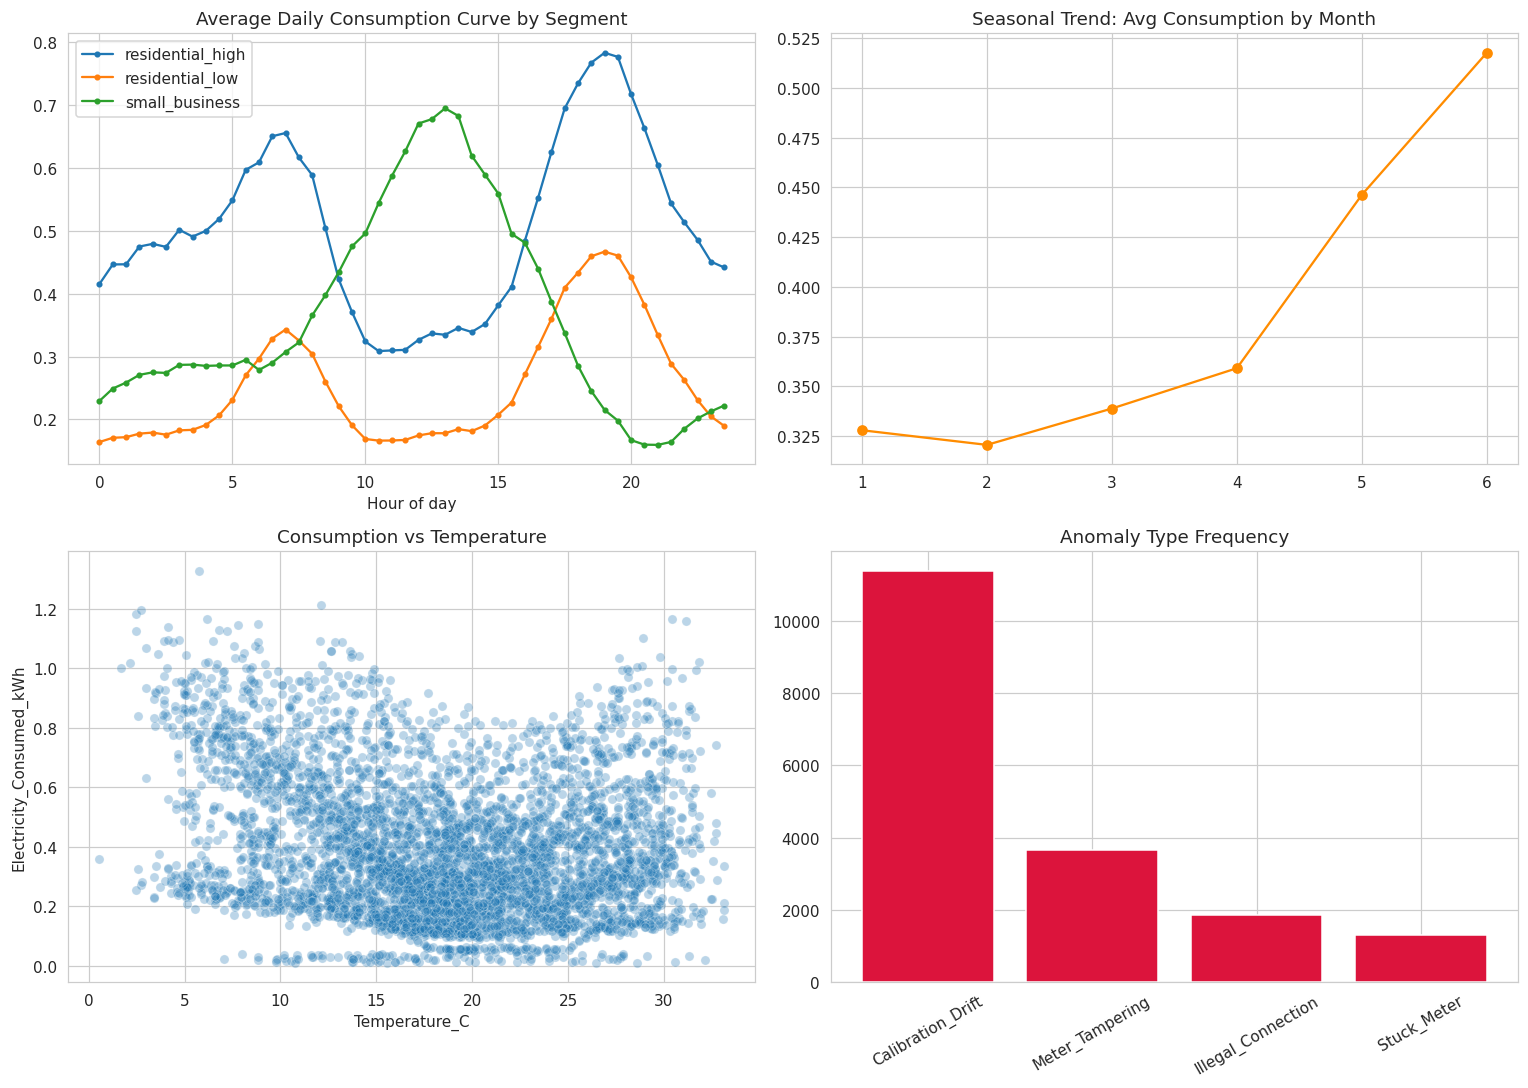

In [0]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

hourly_avg = df[df['Anomaly_Label']=='Normal'].groupby(['Segment','hour'])['Electricity_Consumed_kWh'].mean().reset_index()
for seg in hourly_avg['Segment'].unique():
    sub = hourly_avg[hourly_avg['Segment']==seg]
    axes[0,0].plot(sub['hour'], sub['Electricity_Consumed_kWh'], label=seg, marker='.')
axes[0,0].set_title('Average Daily Consumption Curve by Segment')
axes[0,0].set_xlabel('Hour of day'); axes[0,0].legend()

monthly = df[df['Anomaly_Label']=='Normal'].groupby('month')['Electricity_Consumed_kWh'].mean()
axes[0,1].plot(monthly.index, monthly.values, marker='o', color='darkorange')
axes[0,1].set_title('Seasonal Trend: Avg Consumption by Month')

sample = df[df['Anomaly_Label']=='Normal'].sample(5000, random_state=1)
sns.scatterplot(data=sample, x='Temperature_C', y='Electricity_Consumed_kWh', alpha=0.3, ax=axes[1,0])
axes[1,0].set_title('Consumption vs Temperature')

anomaly_counts = df[df['Anomaly_Type']!='None']['Anomaly_Type'].value_counts()
axes[1,1].bar(anomaly_counts.index, anomaly_counts.values, color='crimson')
axes[1,1].set_title('Anomaly Type Frequency')
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## Feature Engineering(per-meter, no leakage)

In [0]:
df = df.sort_values(['Meter_ID','Timestamp']).reset_index(drop=True)

# Lag & rolling features computed PER METER so they never mix data across meters
g = df.groupby('Meter_ID')['Electricity_Consumed_kWh']
df['lag_1']           = g.shift(1)
df['lag_2']           = g.shift(2)
df['lag_48']          = g.shift(48)      # same time yesterday
df['rolling_mean_6']  = g.transform(lambda x: x.rolling(6, min_periods=1).mean())
df['rolling_std_6']   = g.transform(lambda x: x.rolling(6, min_periods=1).std())
df['rolling_mean_48'] = g.transform(lambda x: x.rolling(48, min_periods=1).mean())
df['rolling_std_24']  = g.transform(lambda x: x.rolling(24, min_periods=6).std())

# Baseline built from each meter's FIRST 14 DAYS ONLY (a trusted early window),
# not from Anomaly_Label — using labels here would be leakage, since a real
# deployment wouldn't have fraud labels available at inference time
if 'hourly_baseline' not in df.columns:
    baseline_window = df[df['Timestamp'] < df['Timestamp'].min() + pd.Timedelta(days=14)]
    hourly_baseline = baseline_window.groupby(['Meter_ID','hour'])['Electricity_Consumed_kWh'].mean().rename('hourly_baseline')
    df = df.merge(hourly_baseline, on=['Meter_ID','hour'], how='left')

df['deviation_from_baseline'] = df['Electricity_Consumed_kWh'] - df['hourly_baseline']
df['ratio_to_baseline'] = df['Electricity_Consumed_kWh'] / df['hourly_baseline'].replace(0, np.nan)
df['rolling_ratio_30d'] = df.groupby('Meter_ID')['ratio_to_baseline'].transform(
    lambda x: x.rolling(1440, min_periods=200).mean()  # 1440 steps = 30 days @ 30-min interval
)

if 'Segment' in df.columns:
    df = pd.get_dummies(df, columns=['Segment'], prefix='seg')
df = df.dropna().reset_index(drop=True)
print(df.shape)

(102444, 27)


## Generic anomaly detection (Isolation Forest), excluding known load shedding

In [0]:
# Exclude scheduled load-shedding periods before fraud scoring - these are
# known/expected blackouts, not something a fraud model should evaluate
df_score = df[df['Is_Load_Shedding']==False].copy().reset_index(drop=True)

y_true = (df_score['Anomaly_Label']=='Abnormal').astype(int)

feature_cols = ['Electricity_Consumed_kWh','Temperature_C','Humidity_pct','Wind_Speed_kmh',
                 'hour','dow','is_weekend','month','lag_1','lag_2','lag_48',
                 'rolling_mean_6','rolling_std_6','rolling_mean_48',
                 'deviation_from_baseline','ratio_to_baseline',
                 'seg_residential_high','seg_residential_low','seg_small_business']

X = df_score[feature_cols]
X_scaled = StandardScaler().fit_transform(X)
contamination = y_true.mean()

iso = IsolationForest(contamination=contamination, n_estimators=300, random_state=42)
df_score['iso_pred'] = (iso.fit_predict(X_scaled) == -1).astype(int)

p, r, f1, _ = precision_recall_fscore_support(y_true, df_score['iso_pred'], average='binary', zero_division=0)
print(f"Isolation Forest — Precision={p:.3f} Recall={r:.3f} F1={f1:.3f}")
print(confusion_matrix(y_true, df_score['iso_pred']))

print("\nRecall by fault type:")
print(df_score[df_score['Anomaly_Label']=='Abnormal'].groupby('Anomaly_Type')['iso_pred'].mean())

Isolation Forest — Precision=0.356 Recall=0.356 F1=0.356
[[71009 11543]
 [11543  6381]]

Recall by fault type:
Anomaly_Type
Calibration_Drift     0.161061
Illegal_Connection    0.803456
Meter_Tampering       0.847314
Stuck_Meter           0.008436
Name: iso_pred, dtype: float64


## Specialized detectors for flatline & drift (Ensemble Modelling)

In [0]:
# Flatline detector: near-zero rolling variance = meter has stopped varying (stuck/frozen)
FLATLINE_STD_THRESHOLD = 0.01
df_score['flatline_flag'] = (df_score['rolling_std_24'] < FLATLINE_STD_THRESHOLD).astype(int)

# Drift detector: sustained decline in 30-day rolling ratio-to-baseline
DRIFT_RATIO_THRESHOLD = 0.85
df_score['drift_flag'] = (df_score['rolling_ratio_30d'] < DRIFT_RATIO_THRESHOLD).astype(int)

# Combine all three signals into one audit flag
df_score['combined_flag'] = ((df_score['iso_pred']==1) |
                              (df_score['flatline_flag']==1) |
                              (df_score['drift_flag']==1)).astype(int)

for name, col in [('Isolation Forest alone', 'iso_pred'),
                   ('Flatline detector alone', 'flatline_flag'),
                   ('Drift detector alone', 'drift_flag'),
                   ('Combined system', 'combined_flag')]:
    p, r, f1, _ = precision_recall_fscore_support(y_true, df_score[col], average='binary', zero_division=0)
    print(f"{name}: Precision={p:.3f} Recall={r:.3f} F1={f1:.3f}")

print("\nRecall by fault type — Combined system:")
print(df_score[df_score['Anomaly_Label']=='Abnormal'].groupby('Anomaly_Type')['combined_flag'].mean())

Isolation Forest alone: Precision=0.356 Recall=0.356 F1=0.356
Flatline detector alone: Precision=0.993 Recall=0.082 F1=0.152
Drift detector alone: Precision=0.749 Recall=0.269 F1=0.396
Combined system: Precision=0.433 Recall=0.537 F1=0.480

Recall by fault type — Combined system:
Anomaly_Type
Calibration_Drift     0.317986
Illegal_Connection    0.803456
Meter_Tampering       0.976974
Stuck_Meter           0.801380
Name: combined_flag, dtype: float64


## Visualize the improvement

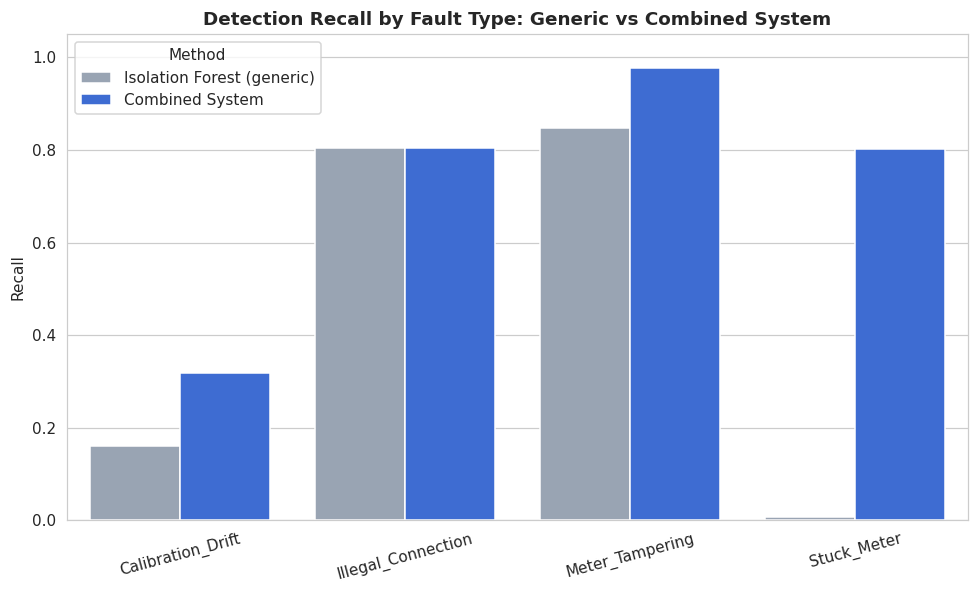

In [0]:
recall_data = {
    'Isolation Forest (generic)': df_score[df_score['Anomaly_Label']=='Abnormal'].groupby('Anomaly_Type')['iso_pred'].mean(),
    'Combined System': df_score[df_score['Anomaly_Label']=='Abnormal'].groupby('Anomaly_Type')['combined_flag'].mean(),
}
recall_df = pd.DataFrame(recall_data).reset_index().melt(id_vars='Anomaly_Type', var_name='Method', value_name='Recall')

fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(data=recall_df, x='Anomaly_Type', y='Recall', hue='Method', ax=ax, palette=['#94a3b8','#2563eb'])
ax.set_title('Detection Recall by Fault Type: Generic vs Combined System', fontweight='bold')
ax.set_ylim(0,1.05); ax.set_xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()